# The-KISS NCA — Fine-tune from an Old Grow Model

This notebook starts from a previously trained NCA checkpoint and fine-tunes a **new/student model** for better details and long-step persistence.

Key differences from the original notebook:

1. The **old model is frozen**.
2. Every training input batch is generated by the **old model**, starting from the seed.
3. The new model is initialized from the selected old weights.
4. There is **no new-model pattern pool**. The student never trains from its own accumulated pool states.
5. The student is trained with a higher maximum step count to improve persistence.
6. The loss includes pixel loss, detail/gradient loss, and L2 regularization on the parameters.
7. Optional L2-anchor regularization keeps the fine-tuned parameters close to the original grow model.


In [1]:
#@title Imports and Notebook Utilities
import os
import io
import base64
import json
import glob
from pathlib import Path

import numpy as np
import matplotlib.pylab as pl
import matplotlib.pyplot as plt
import PIL.Image
import tensorflow as tf
import tqdm

from IPython.display import Image, clear_output, display
from tensorflow.keras.layers import Conv2D
from google.protobuf.json_format import MessageToDict
from tensorflow.python.framework import convert_to_constants

os.environ['FFMPEG_BINARY'] = 'ffmpeg'
import moviepy.editor as mvp
from moviepy.video.io.ffmpeg_writer import FFMPEG_VideoWriter


def np2pil(a):
  if a.dtype in [np.float32, np.float64]:
    a = np.uint8(np.clip(a, 0, 1)*255)
  return PIL.Image.fromarray(a)


def imwrite(f, a, fmt=None):
  a = np.asarray(a)
  if isinstance(f, str):
    fmt = f.rsplit('.', 1)[-1].lower()
    if fmt == 'jpg':
      fmt = 'jpeg'
    f = open(f, 'wb')
  np2pil(a).save(f, fmt, quality=95)


def imencode(a, fmt='jpeg'):
  a = np.asarray(a)
  if len(a.shape) == 3 and a.shape[-1] == 4:
    fmt = 'png'
  f = io.BytesIO()
  imwrite(f, a, fmt)
  return f.getvalue()


def imshow(a, fmt='jpeg'):
  display(Image(data=imencode(a, fmt)))


def tile2d(a, w=None):
  a = np.asarray(a)
  if w is None:
    w = int(np.ceil(np.sqrt(len(a))))
  th, tw = a.shape[1:3]
  pad = (w-len(a))%w
  a = np.pad(a, [(0, pad)]+[(0, 0)]*(a.ndim-1), 'constant')
  h = len(a)//w
  a = a.reshape([h, w]+list(a.shape[1:]))
  a = np.rollaxis(a, 2, 1).reshape([th*h, tw*w]+list(a.shape[4:]))
  return a


def zoom(img, scale=4):
  img = np.repeat(img, scale, 0)
  img = np.repeat(img, scale, 1)
  return img


class VideoWriter:
  def __init__(self, filename, fps=30.0, **kw):
    self.writer = None
    self.params = dict(filename=filename, fps=fps, **kw)

  def add(self, img):
    img = np.asarray(img)
    if self.writer is None:
      h, w = img.shape[:2]
      self.writer = FFMPEG_VideoWriter(size=(w, h), **self.params)
    if img.dtype in [np.float32, np.float64]:
      img = np.uint8(img.clip(0, 1)*255)
    if len(img.shape) == 2:
      img = np.repeat(img[..., None], 3, -1)
    self.writer.write_frame(img)

  def close(self):
    if self.writer:
      self.writer.close()

  def __enter__(self):
    return self

  def __exit__(self, *kw):
    self.close()


/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:294: SyntaxWarning: invalid escape sequence '\d'
  lines_video = [l for l in lines if ' Video: ' in l and re.search('\d+x\d+', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:367: SyntaxWarning: invalid escape sequence '\d'
  rotation_lines = [l for l in lines if 'rotate          :' in l and re.search('\d+$', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:370: SyntaxWarning: invalid escape sequence '\d'
  match = re.search('\d+$', rotation_line)
  if event.key is 'enter':



In [2]:
#@title Fine-tuning Parameters {vertical-output: true}
CHANNEL_N = 16
TARGET_PADDING = 0
TARGET_SIZE = 64
BATCH_SIZE = 8
CELL_FIRE_RATE = 0.5

# Target image
PAINTINGS_DIR = Path('')
AVAILABLE_PAINTINGS = sorted(PAINTINGS_DIR.glob('*.png'))
print('Available paintings:')
for painting_path in AVAILABLE_PAINTINGS:
  print(' -', painting_path.stem)

TARGET_PAINTING = 'the_kiss'  #@param {type:"string"}

# Old checkpoint selection.
# Put here the checkpoint produced by your previous/grow notebook.
# Example: train_log/the_kiss/final.weights.h5 or train_log/the_kiss/0800.weights.h5
OLD_WEIGHTS_PATH = '1200.weights.h5'  #@param {type:"string"}

print('\\nAvailable .weights.h5 files found from current folder:')
for w in sorted(Path('').glob('**/*.weights.h5'))[:50]:
  print(' -', w)
if len(list(Path('').glob('**/*.weights.h5'))) > 50:
  print(' ... more files not shown')

# Fine-tuning length
NUM_FINETUNE_STEPS = 1500  #@param {type:"integer"}

# Teacher/old-model input generation.
# Each batch is produced by the frozen old model from the seed.
TEACHER_INPUT_MIN_STEPS = 64    #@param {type:"integer"}
TEACHER_INPUT_MAX_STEPS = 256   #@param {type:"integer"}
TEACHER_FIRE_RATE = 1.0         #@param {type:"number"}

# Student/new-model persistence horizon.
# This is intentionally higher than the original notebook.
FT_STEP_MIN = 128       #@param {type:"integer"}
FT_STEP_MAX = 512       #@param {type:"integer"}

# Loss weights.
RGB_W = 3.0             #@param {type:"number"}
A_W = 0.35              #@param {type:"number"}
DETAIL_W = 0.20         #@param {type:"number"}

# Mid/final persistence losses.
# Mid loss prevents the student from drifting too much during the first part of the rollout.
# Final loss pushes details after longer evolution.
W_MID_LOSS = 0.20       #@param {type:"number"}
W_FINAL_LOSS = 0.80     #@param {type:"number"}

# L2 regularization.
# L2_PARAM_W is standard weight decay on student parameters.
# L2_ANCHOR_W keeps the fine-tuned student close to the old grow model weights.
L2_PARAM_W = 1e-6       #@param {type:"number"}
L2_ANCHOR_W = 1e-5      #@param {type:"number"}

# Learning rate
LR = 5e-4               #@param {type:"number"}
LR_DECAY_STEP_1 = 1200  #@param {type:"integer"}
LR_DECAY_STEP_2 = 2400  #@param {type:"integer"}

# Logging/checkpoints
EXPORT_EVERY = 100      #@param {type:"integer"}
VIS_EVERY = 100         #@param {type:"integer"}

FINETUNE_RUN_NAME = 'detail_persist_from_old'  #@param {type:"string"}


Available paintings:
 - the_kiss
\nAvailable .weights.h5 files found from current folder:
 - 1200.weights.h5


In [3]:
#@title CA Model and Utilities

def plot_seed_pool_loss(loss_log, seed_loss_log, pool_loss_log):
  plt.figure(figsize=(8, 4))

  plt.plot(np.log10(loss_log), label='Total loss')
  plt.plot(np.log10(seed_loss_log), label='Seed loss')
  plt.plot(np.log10(pool_loss_log), label='Pool loss')

  plt.xlabel('Training step')
  plt.ylabel('log10(loss)')
  plt.legend()
  plt.grid(True)
  plt.show()

def load_painting(name, max_size=TARGET_SIZE):
  path = PAINTINGS_DIR / f'{name}.png'
  img = PIL.Image.open(path).convert('RGBA')
  if img.size != (max_size, max_size):
    img = img.resize((max_size, max_size), PIL.Image.LANCZOS)
  img = np.float32(img)/255.0
  # Match the reference NCA target representation: premultiply RGB by alpha.
  img[..., :3] *= img[..., 3:]
  return img


def to_rgba(x):
  return x[..., :4]


def to_alpha(x):
  return tf.clip_by_value(x[..., 3:4], 0.0, 1.0)


def to_rgb(x):
  # Assume RGB is premultiplied by alpha, as in the reference notebook.
  rgb, a = x[..., :3], to_alpha(x)
  return 1.0-a+rgb


def get_living_mask(x):
  alpha = x[:, :, :, 3:4]
  return tf.nn.max_pool2d(alpha, 3, [1, 1, 1, 1], 'SAME') > 0.1


def make_seed(size, n=1):
  x = np.zeros([n, size, size, CHANNEL_N], np.float32)
  x[:, size//2, size//2, 3:] = 1.0
  return x


class CAModel(tf.keras.Model):

  def __init__(self, channel_n=CHANNEL_N, fire_rate=CELL_FIRE_RATE):
    super().__init__()
    self.channel_n = channel_n
    self.fire_rate = fire_rate

    self.dmodel = tf.keras.Sequential([
          Conv2D(128, 1, activation=tf.nn.relu),
          Conv2D(self.channel_n, 1, activation=None,
              kernel_initializer=tf.zeros_initializer),
    ])

    self(tf.zeros([1, 3, 3, channel_n]))  # Dummy call to build the model.

  @tf.function
  def perceive(self, x, angle=0.0):
    identify = np.float32([0, 1, 0])
    identify = np.outer(identify, identify)
    dx = np.outer([1, 2, 1], [-1, 0, 1]) / 8.0  # Sobel filter.
    dy = dx.T
    c, s = tf.cos(angle), tf.sin(angle)
    kernel = tf.stack([identify, c*dx-s*dy, s*dx+c*dy], -1)[:, :, None, :]
    kernel = tf.repeat(kernel, self.channel_n, 2)
    y = tf.nn.depthwise_conv2d(x, kernel, [1, 1, 1, 1], 'SAME')
    return y

  @tf.function
  def call(self, x, fire_rate=None, angle=0.0, step_size=1.0):
    pre_life_mask = get_living_mask(x)

    y = self.perceive(x, angle)
    dx = self.dmodel(y)*step_size
    if fire_rate is None:
      fire_rate = self.fire_rate
    update_mask = tf.random.uniform(tf.shape(x[:, :, :, :1])) <= fire_rate
    x += dx * tf.cast(update_mask, tf.float32)

    post_life_mask = get_living_mask(x)
    life_mask = pre_life_mask & post_life_mask
    return x * tf.cast(life_mask, tf.float32)


CAModel().dmodel.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (1, 3, 3, 128)         │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (1, 3, 3, 16)          │         2,064 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,336 (32.56 KB)

 Trainable params: 8,336 (32.56 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
#@title Fine-tune Plot Utilities
def plot_finetune_losses(logs):
  plt.figure(figsize=(10, 4))
  for key, values in logs.items():
    if len(values) and key in ['total', 'mid', 'final_base', 'detail', 'l2_param', 'l2_anchor']:
      arr = np.asarray(values, dtype=np.float32)
      arr = np.where(arr > 0, arr, np.nan)
      plt.plot(np.log10(arr), '.', alpha=0.25, label=key)
  plt.xlabel('Fine-tune step')
  plt.ylabel('log10(loss)')
  plt.title('Fine-tuning losses')
  plt.legend()
  plt.grid(True)
  plt.show()


def visualize_finetune_batch(x0, x_mid, x_final, step_i, log_dir):
  vis0 = np.hstack(to_rgb(x0).numpy())
  vis_mid = np.hstack(to_rgb(x_mid).numpy())
  vis_final = np.hstack(to_rgb(x_final).numpy())
  vis = np.vstack([vis0, vis_mid, vis_final])
  imwrite(str(log_dir / f'finetune_batch_{step_i:04d}.jpg'), vis)
  print('batch: old-model input / student mid / student final')
  imshow(vis)


In [5]:
#@title Train Utilities (SamplePool, Model Export, Damage, Visualization)
class SamplePool:
  def __init__(self, *, _parent=None, _parent_idx=None, **slots):
    self._parent = _parent
    self._parent_idx = _parent_idx
    self._slot_names = slots.keys()
    self._size = None
    for k, v in slots.items():
      if self._size is None:
        self._size = len(v)
      assert self._size == len(v)
      setattr(self, k, np.asarray(v))

  def sample(self, n):
    idx = np.random.choice(self._size, n, False)
    batch = {k: getattr(self, k)[idx] for k in self._slot_names}
    batch = SamplePool(**batch, _parent=self, _parent_idx=idx)
    return batch

  def commit(self):
    for k in self._slot_names:
      getattr(self._parent, k)[self._parent_idx] = getattr(self, k)


@tf.function
def make_circle_masks(n, h, w):
  x = tf.linspace(-1.0, 1.0, w)[None, None, :]
  y = tf.linspace(-1.0, 1.0, h)[None, :, None]
  center = tf.random.uniform([2, n, 1, 1], -0.5, 0.5)
  r = tf.random.uniform([n, 1, 1], 0.1, 0.4)
  x, y = (x-center[0])/r, (y-center[1])/r
  mask = tf.cast(x*x+y*y < 1.0, tf.float32)
  return mask


def export_model(ca, base_fn):
  base_fn = str(base_fn)
  weights_path = base_fn + '.weights.h5'
  ca.save_weights(weights_path)

  cf = ca.call.get_concrete_function(
      x=tf.TensorSpec([None, None, None, CHANNEL_N]),
      fire_rate=tf.constant(0.5),
      angle=tf.constant(0.0),
      step_size=tf.constant(1.0))
  cf = convert_to_constants.convert_variables_to_constants_v2(cf)
  graph_def = cf.graph.as_graph_def()
  graph_json = MessageToDict(graph_def)
  graph_json['versions'] = dict(producer='1.14', minConsumer='1.14')
  model_json = {
      'format': 'graph-model',
      'modelTopology': graph_json,
      'weightsManifest': [],
  }
  with open(base_fn+'.json', 'w') as f:
    json.dump(model_json, f)


def generate_pool_figures(pool, step_i, log_dir):
  tiled_pool = tile2d(to_rgb(pool.x[:49]))
  fade = np.linspace(1.0, 0.0, TARGET_SIZE + 2*TARGET_PADDING)
  ones = np.ones(TARGET_SIZE + 2*TARGET_PADDING)
  tiled_pool[:, :len(ones)] += (-tiled_pool[:, :len(ones)] + ones[None, :, None]) * fade[None, :, None]
  tiled_pool[:, -len(ones):] += (-tiled_pool[:, -len(ones):] + ones[None, :, None]) * fade[None, ::-1, None]
  tiled_pool[:len(ones), :] += (-tiled_pool[:len(ones), :] + ones[:, None, None]) * fade[:, None, None]
  tiled_pool[-len(ones):, :] += (-tiled_pool[-len(ones):, :] + ones[:, None, None]) * fade[::-1, None, None]
  imwrite(str(log_dir / f'{step_i:04d}_pool.jpg'), tiled_pool)


def visualize_batch(x0, x, step_i, log_dir):
  vis0 = np.hstack(to_rgb(x0).numpy())
  vis1 = np.hstack(to_rgb(x).numpy())
  vis = np.vstack([vis0, vis1])
  imwrite(str(log_dir / f'batches_{step_i:04d}.jpg'), vis)
  print('batch (before/after):')
  imshow(vis)


def plot_loss(loss_log):
  pl.figure(figsize=(10, 4))
  pl.title('Loss history (log10)')
  pl.plot(np.log10(loss_log), '.', alpha=0.1)
  pl.show()


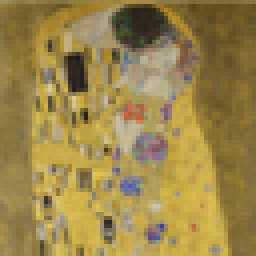

All Klimt painting targets:


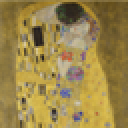

In [6]:
#@title Choose Target Image
target_img = load_painting(TARGET_PAINTING)
imshow(zoom(to_rgb(target_img), 4), fmt='png')

all_targets = [load_painting(p.stem) for p in AVAILABLE_PAINTINGS]
print('All Klimt painting targets:')
if all_targets:
  imshow(zoom(tile2d([to_rgb(img).numpy() for img in all_targets], w=len(all_targets)), 2), fmt='png')
else:
  print("No Klimt painting targets available to display.")

batch: old-model input / student mid / student final


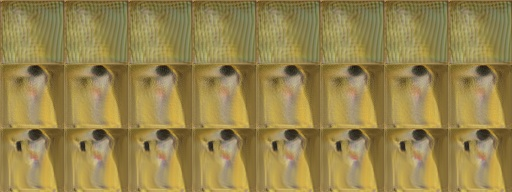

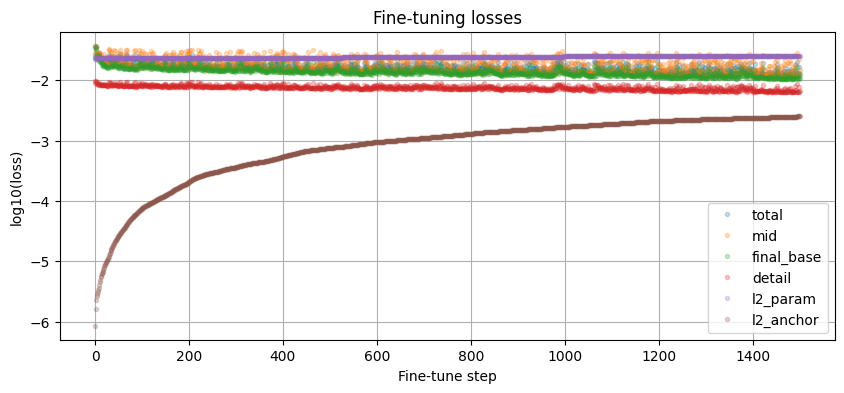

\r step: 1500, log10(loss): -1.890, log10(final): -1.956, log10(detail): -2.175\r step: 1501, log10(loss): -1.911, log10(final): -1.956, log10(detail): -2.176\r step: 1502, log10(loss): -1.917, log10(final): -1.968, log10(detail): -2.187\r step: 1503, log10(loss): -1.715, log10(final): -1.803, log10(detail): -2.073\r step: 1504, log10(loss): -1.905, log10(final): -1.956, log10(detail): -2.180

KeyboardInterrupt: 

In [7]:
#@title Fine-tune Selected Old Weights

def finetune_from_old_model(painting_name=TARGET_PAINTING, old_weights_path=OLD_WEIGHTS_PATH, train_steps=NUM_FINETUNE_STEPS):
  print(f'Fine-tuning target: {painting_name}')
  print(f'Old weights: {old_weights_path}')

  old_weights_path = Path(old_weights_path)
  if not old_weights_path.exists():
    raise FileNotFoundError(
        f'Could not find OLD_WEIGHTS_PATH: {old_weights_path}\\n'
        'Check the path printed in the parameters cell, or upload/copy the old .weights.h5 file.'
    )

  target_img = load_painting(painting_name)

  log_dir = Path('finetune_log') / painting_name / FINETUNE_RUN_NAME
  log_dir.mkdir(parents=True, exist_ok=True)
  for old_file in log_dir.glob('*'):
    old_file.unlink()

  p = TARGET_PADDING
  pad_target = tf.pad(target_img, [(p, p), (p, p), (0, 0)])
  h, w = pad_target.shape[:2]

  seed_np = np.zeros([h, w, CHANNEL_N], np.float32)
  seed_np[h//2, w//2, 3:] = 1.0
  seed_tf = tf.constant(seed_np[None, ...], tf.float32)

  def loss_f(x):
    pred = to_rgba(x)
    diff_rgb = tf.square(pred[..., :3] - pad_target[None, ..., :3])
    diff_a = tf.square(pred[..., 3:4] - pad_target[None, ..., 3:4])
    return tf.reduce_mean(diff_rgb * RGB_W + diff_a * A_W, [-2, -3, -1])

  def gradient_loss_f(x):
    pred = to_rgba(x)
    pred_rgb = pred[..., :3]
    target_rgb = pad_target[None, ..., :3]

    pred_dx = pred_rgb[:, :, 1:, :] - pred_rgb[:, :, :-1, :]
    target_dx = target_rgb[:, :, 1:, :] - target_rgb[:, :, :-1, :]

    pred_dy = pred_rgb[:, 1:, :, :] - pred_rgb[:, :-1, :, :]
    target_dy = target_rgb[:, 1:, :, :] - target_rgb[:, :-1, :, :]

    loss_dx = tf.reduce_mean(tf.square(pred_dx - target_dx), [-2, -3, -1])
    loss_dy = tf.reduce_mean(tf.square(pred_dy - target_dy), [-2, -3, -1])
    return loss_dx + loss_dy

  # Frozen teacher: generates all input batches.
  old_ca = CAModel()
  old_ca.load_weights(str(old_weights_path))
  old_ca.trainable = False

  # Student: initialized from the same old weights, then fine-tuned.
  ca = CAModel()
  ca.load_weights(str(old_weights_path))

  # Store old parameters for L2-anchor regularization.
  old_trainable_weights = [tf.identity(w) for w in ca.trainable_weights]

  lr_sched = tf.keras.optimizers.schedules.PiecewiseConstantDecay(
      [LR_DECAY_STEP_1, LR_DECAY_STEP_2],
      [LR, LR * 0.5, LR * 0.2]
  )
  trainer = tf.keras.optimizers.Adam(lr_sched)

  logs = {
      'total': [],
      'mid': [],
      'final_base': [],
      'detail': [],
      'l2_param': [],
      'l2_anchor': [],
      'old_input': [],
  }

  @tf.function
  def make_old_model_batch():
    x = tf.repeat(seed_tf, BATCH_SIZE, axis=0)
    teacher_steps = tf.random.uniform([], TEACHER_INPUT_MIN_STEPS, TEACHER_INPUT_MAX_STEPS, tf.int32)

    for _ in tf.range(teacher_steps):
      x = old_ca(x, fire_rate=tf.constant(TEACHER_FIRE_RATE, tf.float32))

    return tf.stop_gradient(x)

  @tf.function
  def train_step():
    # Input always comes from the frozen old model.
    # There is no student/new-model pattern pool here.
    x0 = make_old_model_batch()

    student_steps = tf.random.uniform([], FT_STEP_MIN, FT_STEP_MAX, tf.int32)
    mid_n = student_steps // 2

    with tf.GradientTape() as g:
      x = x0

      for _ in tf.range(mid_n):
        x = ca(x)

      x_mid = x
      loss_mid = tf.reduce_mean(loss_f(x_mid))

      for _ in tf.range(student_steps - mid_n):
        x = ca(x)

      x_final = x

      loss_final_base = tf.reduce_mean(loss_f(x_final))
      loss_detail = tf.reduce_mean(gradient_loss_f(x_final))

      l2_param = tf.add_n([tf.reduce_mean(tf.square(w)) for w in ca.trainable_weights])
      l2_anchor = tf.add_n([
          tf.reduce_mean(tf.square(w - old_w))
          for w, old_w in zip(ca.trainable_weights, old_trainable_weights)
      ])

      loss = (
          W_MID_LOSS * loss_mid
          + W_FINAL_LOSS * (loss_final_base + DETAIL_W * loss_detail)
          + L2_PARAM_W * l2_param
          + L2_ANCHOR_W * l2_anchor
      )

    grads = g.gradient(loss, ca.trainable_weights)
    grads = [grad / (tf.norm(grad) + 1e-8) for grad in grads]
    trainer.apply_gradients(zip(grads, ca.trainable_weights))

    old_input_loss = tf.reduce_mean(loss_f(x0))

    return x0, x_mid, x_final, loss, loss_mid, loss_final_base, loss_detail, l2_param, l2_anchor, old_input_loss

  for i in range(train_steps + 1):
    x0, x_mid, x_final, loss, loss_mid, loss_final_base, loss_detail, l2_param, l2_anchor, old_input_loss = train_step()

    logs['total'].append(float(loss.numpy()))
    logs['mid'].append(float(loss_mid.numpy()))
    logs['final_base'].append(float(loss_final_base.numpy()))
    logs['detail'].append(float(loss_detail.numpy()))
    logs['l2_param'].append(float(l2_param.numpy()))
    logs['l2_anchor'].append(float(l2_anchor.numpy()))
    logs['old_input'].append(float(old_input_loss.numpy()))

    step_i = len(logs['total']) - 1

    if step_i % VIS_EVERY == 0:
      clear_output()
      visualize_finetune_batch(x0, x_mid, x_final, step_i, log_dir)
      plot_finetune_losses(logs)

    if step_i % EXPORT_EVERY == 0:
      export_model(ca, log_dir / f'{step_i:04d}')

    """print(
      '\\r step: %d, log10(loss): %.3f, log10(final): %.3f, log10(detail): %.3f'
      % (
          step_i,
          np.log10(max(logs['total'][-1], 1e-12)),
          np.log10(max(logs['final_base'][-1], 1e-12)),
          np.log10(max(logs['detail'][-1], 1e-12)),
      ),
      end=''
    )"""

  export_model(ca, log_dir / 'final')

  for key, values in logs.items():
    np.save(log_dir / f'{key}_log.npy', np.asarray(values, dtype=np.float32))

  with open(log_dir / 'finetune_config.json', 'w') as f:
    json.dump({
        'painting_name': painting_name,
        'old_weights_path': str(old_weights_path),
        'CHANNEL_N': CHANNEL_N,
        'TARGET_PADDING': TARGET_PADDING,
        'TARGET_SIZE': TARGET_SIZE,
        'BATCH_SIZE': BATCH_SIZE,
        'CELL_FIRE_RATE': CELL_FIRE_RATE,
        'TEACHER_INPUT_MIN_STEPS': TEACHER_INPUT_MIN_STEPS,
        'TEACHER_INPUT_MAX_STEPS': TEACHER_INPUT_MAX_STEPS,
        'TEACHER_FIRE_RATE': TEACHER_FIRE_RATE,
        'FT_STEP_MIN': FT_STEP_MIN,
        'FT_STEP_MAX': FT_STEP_MAX,
        'RGB_W': RGB_W,
        'A_W': A_W,
        'DETAIL_W': DETAIL_W,
        'W_MID_LOSS': W_MID_LOSS,
        'W_FINAL_LOSS': W_FINAL_LOSS,
        'L2_PARAM_W': L2_PARAM_W,
        'L2_ANCHOR_W': L2_ANCHOR_W,
        'LR': LR,
    }, f, indent=2)

  print(f'\\nSaved fine-tuned weights, logs, visuals, and config in: {log_dir}')
  return ca, logs, log_dir


ca, logs, log_dir = finetune_from_old_model()


# Fine-tune Figures


In [11]:
#@title Fine-tuned Checkpoint Growth/Persistence Comparison
painting_name = TARGET_PAINTING
log_dir = Path('finetune_log') / painting_name / FINETUNE_RUN_NAME
checkpoint_steps = [0, 100, 500, 1000, 1500]
models = []
loaded_steps = []

for step in checkpoint_steps:
  weights_path = log_dir / f'{step:04d}.weights.h5'
  if weights_path.exists():
    ca_step = CAModel()
    ca_step.load_weights(str(weights_path))
    models.append(ca_step)
    loaded_steps.append(step)

final_weights_path = log_dir / 'final.weights.h5'
if final_weights_path.exists():
  ca_final = CAModel()
  ca_final.load_weights(str(final_weights_path))
  models.append(ca_final)
  loaded_steps.append('final')

if not models:
  raise ValueError('No fine-tune checkpoint weights found. Run the fine-tuning cell first.')

out_fn = str(log_dir / 'finetune_checkpoints_growth.mp4')
x = np.zeros([len(models), TARGET_SIZE + 2*TARGET_PADDING, TARGET_SIZE + 2*TARGET_PADDING, CHANNEL_N], np.float32)
x[:, x.shape[1]//2, x.shape[2]//2, 3:] = 1.0

with VideoWriter(out_fn) as vid:
  for _ in tqdm.trange(700):
    vis = np.hstack(to_rgb(x))
    vid.add(zoom(vis, 2))
    for ca_step, xk in zip(models, x):
      xk[:] = ca_step(xk[None, ...])[0]

print('Loaded checkpoints:', loaded_steps)
mvp.ipython_display(out_fn)


100%|██████████| 700/700 [00:18<00:00, 37.65it/s]


Loaded checkpoints: [0, 100, 500, 1000, 1500]


In [12]:
#@title Fine-tune Batch Progress Video
frames = sorted(glob.glob(str(log_dir / 'finetune_batch_*.jpg')))
if not frames:
  raise ValueError('No finetune_batch_*.jpg frames found. Run the fine-tuning cell first.')

clip_path = str(log_dir / 'finetune_batches.mp4')
mvp.ImageSequenceClip(frames, fps=10.0).write_videofile(clip_path)
mvp.ipython_display(clip_path)


Moviepy - Building video finetune_log/the_kiss/detail_persist_from_old/finetune_batches.mp4.
Moviepy - Writing video finetune_log/the_kiss/detail_persist_from_old/finetune_batches.mp4



Moviepy - Done !
Moviepy - video ready finetune_log/the_kiss/detail_persist_from_old/finetune_batches.mp4


In [14]:
#@title Zip Fine-tune Log
import shutil
try:
  from google.colab import files
  can_download = True
except Exception:
  can_download = False

zip_base = str(Path('finetune_log') / f'{TARGET_PAINTING}_{FINETUNE_RUN_NAME}')
shutil.make_archive(zip_base, 'zip', str(Path('finetune_log') / TARGET_PAINTING / FINETUNE_RUN_NAME))
print('Created:', zip_base + '.zip')

if can_download:
  files.download(zip_base + '.zip')


Created: finetune_log/the_kiss_detail_persist_from_old.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>